In [1]:
import pydantic
!pip install langchain langgraph langchain-core langchain-community langchain_groq

State schema
first define the state of the graph
the state schema serves as the input schema for all Nodes and Edges for all Nodes and Edges in the graph
We use Typed Dict class from python's typing_extensions Module as schema which provides type hints for the keys

In [ ]:
from typing_extensions import TypedDict
#dict format for state schema

class State(TypedDict):
  graph_info:str

Nodes : python functions

In [ ]:
def start_play(state:State):
  print("start playing node invoked")
  return {"graph_info":state["graph_info"]+"I am planning to play"}

def cricket(state:State):
  print("cricket node invoked")
  return {"graph_info":state["graph_info"]+" cricket"}

def golf(state:State):
    print("golf node invoked")
    return {"graph_info":state["graph_info"]+" golf"}



In [ ]:
import random
from typing import Literal

def random_play(state:State) -> Literal["cricket","golf"]:
  print("random play node invoked")
  return random.choice(["cricket","golf"])

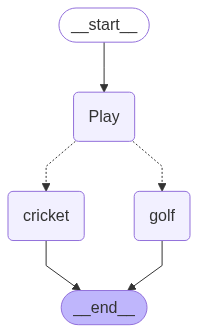

In [ ]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

#build graph
graph = StateGraph(State)
#add nodes
graph.add_node("Play",start_play)
graph.add_node("cricket",cricket)
graph.add_node("golf",golf)

# Scheduling the flow of graph
graph.add_edge(START,"Play")
graph.add_conditional_edges("Play", random_play)
graph.add_edge("cricket",END)
graph.add_edge("golf",END)

#compile the graph
graph_builder = graph.compile()

#View
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
graph_builder.invoke({"graph_info":"Lets Play!"})

start playing node invoked
random play node invoked
golf node invoked


{'graph_info': 'Lets Play!I am planning to play golf'}

# AI chatbot using LangGraph

In [ ]:
import pydantic
!pip install langchain langgraph langchain-core langchain-community langchain-groq python-dotenv Arxiv Wikipedia

In [ ]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

In [ ]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=3, doc_content_chars_max = 500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query ArXiv papers")
print(arxiv.name)

arxiv


In [ ]:
arxiv.invoke("Attention is all you need")

"Published: 2024-07-22\nTitle: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models\nAuthors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini\nSummary: The inference demand for LLMs has skyrocketed in recent months, and serving\nmodels with low latencies remains challenging due to the quadratic input length\ncomplexity of the attention layers. In this work, we investigate the effect of\ndropping MLP and attention layers at inference time o"

In [ ]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max = 500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki, description="Query Wikipedia")
print(wiki.name)

wikipedia


In [ ]:
wiki.invoke("LLMs")

'Page: Large language model\nSummary: A large language model (LLM) is a language model trained with self-supervised machine learning on a vast amount of text, designed for natural language processing tasks, especially language generation.\nThe largest and most capable LLMs are generative pretrained transformers (GPTs), which are largely used in generative chatbots such as ChatGPT, Gemini or Claude. LLMs can be fine-tuned for specific tasks or guided by prompt engineering. These models acquire predi'

In [ ]:
import os
os.environ["GROQ_API_KEY"]= ""

In [ ]:
# combine all tools
tools = [arxiv, wiki]

In [ ]:
# initialize the llm model
from langchain_groq import ChatGroq
llm= ChatGroq(model= "qwen/qwen3-32b")
llm.invoke("who are you")

AIMessage(content="<think>\nHmm, the user is asking who I am. First, I need to confirm if they want a basic introduction or a more detailed explanation of my background. As a large language model, I should clearly state my identity and main functions while keeping it concise and avoiding overly technical terms. The user might be a new user unfamiliar with my functions, or they might want to understand my capabilities and limitations. I should provide a simple introduction, including my name, purpose, and how I can help them, without being too verbose. Additionally, I should invite them to ask any specific questions they have so I can assist more effectively. I need to maintain a friendly and professional tone, avoiding any overly complex language. Also, I should check if there are any other possible needs behind their question, such as wanting to know my training data or technical details, but since the question is about identity, the response should focus on that. I should keep it str

In [ ]:
llm_with_tools = llm.bind_tools(tools = tools)
llm_with_tools.invoke("What is the recent news on AI")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news on AI. Let me check the tools available. There\'s arxiv and wikipedia. Arxiv is for academic papers, which might include the latest research. Wikipedia usually has more general information and might not be as up-to-date on the newest news. Since the user wants recent news, arxiv would be better for the latest studies and developments. I should use the arxiv function with a query like "recent advancements in AI" or "latest AI research". That should fetch the most recent papers. Let me make sure the query is broad enough to cover various aspects of AI. Maybe just "recent AI news" as the query. Yeah, that should work.\n', 'tool_calls': [{'id': 'e8vzbxq01', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'arxiv'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 168, 'prompt_tokens': 208, 'total_tokens': 376, 'completion_time': 0.44468094, 'p

In [ ]:
# Workflow
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage ## Human or AI messages
from typing import Annotated #labelling
from langgraph.graph.message import add_messages ## reducers in langgraph

In [ ]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages]


In [ ]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


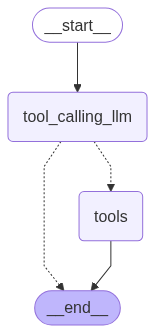

In [ ]:
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# build graph
builder =StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                              # if the latest message(result) from assistant is a tool call it will go to tools else to END
                              tools_condition)

builder.add_edge("tools",END)
graph = builder.compile()

display(Image(builder.compile().get_graph().draw_mermaid_png()))


In [ ]:
messages = graph.invoke({"messages":"1706.03762"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (vk0zfae50)
 Call ID: vk0zfae50
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks in an encoder-decoder configuration. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer, base


In [ ]:
messages = graph.invoke({"messages":"Can you tell me a joke about recent LLM paper released by Google"})
for m in messages['messages']:
    m.pretty_print()

    # only once tool called

================================ Human Message =================================

Can you tell me a joke about recent LLM paper released by Google
================================== Ai Message ==================================
Tool Calls:
  arxiv (ypwz2men1)
 Call ID: ypwz2men1
  Args:
    query: Large Language Model AND Google
================================= Tool Message =================================
Name: arxiv

Published: 2024-09-16
Title: Evaluation of Google Translate for Mandarin Chinese translation using sentiment and semantic analysis
Authors: Xuechun Wang, Rodney Beard, Rohitash Chandra
Summary: Machine translation using large language models (LLMs) is having a
significant global impact, making communication easier. Mandarin Chinese is the
official language used for communication by the government and media in China.
In this study, we provide an automated assessment of translation quality of
Goog


# REACT AGENT

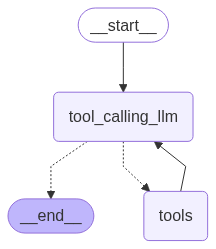

In [ ]:
builder =StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                              # if the latest message(result) from assistant is a tool call it will go to tools
                              tools_condition)

builder.add_edge("tools","tool_calling_llm")
graph = builder.compile()

display(Image(builder.compile().get_graph().draw_mermaid_png()))

In [ ]:
messages = graph.invoke({"messages":"Can you tell me a joke about recent LLM paper released by Google and make that joke mentions company's CEO"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Can you tell me a joke about recent LLM paper released by Google and make that joke mentions company's CEO
================================== Ai Message ==================================
Tool Calls:
  arxiv (6h9dv5nkj)
 Call ID: 6h9dv5nkj
  Args:
    query: recent LLM papers Google
  wikipedia (vhk29zqdd)
 Call ID: vhk29zqdd
  Args:
    query: Google CEO
================================= Tool Message =================================
Name: arxiv

Published: 2024-03-28
Title: A Review of Multi-Modal Large Language and Vision Models
Authors: Kilian Carolan, Laura Fennelly, Alan F. Smeaton
Summary: Large Language Models (LLMs) have recently emerged as a focal point of
research and application, driven by their unprecedented ability to understand
and generate text with human-like quality. Even more recently, LLMs have been
extended into multi-modal large language models (MM-LLMs) which extends their
capabilit

CHATBOT WITH MEMORY

In [ ]:
import os
os.environ["GROQ_API_KEY"]= ""

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [ ]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm= ChatGroq(model= "qwen/qwen3-32b")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x7ed947127b50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7ed947604750>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [ ]:
llm=init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x7ed9478c7c10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7ed9478b08d0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

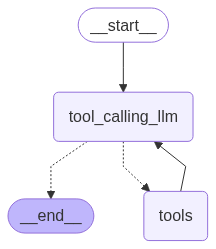

In [ ]:
builder =StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                              # if the latest message(result) from assistant is a tool call it will go to tools
                              tools_condition)

builder.add_edge("tools","tool_calling_llm")
graph = builder.compile()

display(Image(builder.compile().get_graph().draw_mermaid_png()))

In [ ]:
response=graph.invoke({"messages":"Hello my name is chaitanya"})
for m in response['messages']:
    m.pretty_print()
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()  #### See the output needs to add a memory definitely

================================ Human Message =================================

Hello my name is chaitanya
================================== Ai Message ==================================

Hello Chaitanya! How can I assist you today?
================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have access to your personal information, including your name. You can tell me your name if you'd like me to address you by it, but I won't store or use it beyond our current conversation. Do you want to share your name with me?


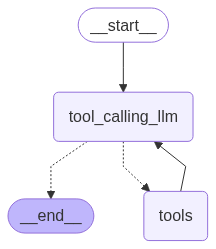

In [ ]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() # in-memory checkpoint saver

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# thread denotes session key
config = {"configurable":{"thread_id":"1"}}
response = graph.invoke({"messages":"Hi I am chaitanya"},config =config)
print(response["messages"][-1].content)
response=graph.invoke({"messages":"Hey who am I"},config=config)
print(response['messages'][-1].content)


Hello Chaitanya! How can I assist you today?
You are Chaitanya, as you introduced earlier. How can I assist you?


# Streaming

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [ ]:
def superbot(state:State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

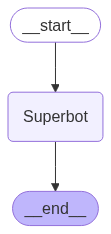

In [ ]:
graph =StateGraph(State)

graph.add_node("Superbot",superbot)
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder = graph.compile(checkpointer=memory)


##
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable":{"thread_id":"1"}}
response = graph_builder.invoke({"messages":"Hi I am chaitanya and I like to play badminton."},config =config)
print(response)

{'messages': [HumanMessage(content='Hi I am chaitanya and I like to play badminton.', additional_kwargs={}, response_metadata={}, id='813c20c9-d21f-4aae-aa4f-b3f016a53e11'), AIMessage(content="Hello Chaitanya! Nice to meet you. Badminton is a fantastic sport – it's great for improving agility and hand-eye coordination. Do you play casually or competitively? Let me know if you'd like tips for improving your game or information about badminton techniques!", additional_kwargs={'reasoning_content': 'Okay, the user introduced themselves as Chaitanya and mentioned they like playing badminton. Let me think about how to respond appropriately.\n\nFirst, I should acknowledge their introduction. A simple "Nice to meet you" seems right. Then, since they mentioned badminton, I can express interest in that. Maybe ask if they play regularly or if they have any tips for improving their game. That keeps the conversation going and shows I\'m engaged. \n\nWait, but the user didn\'t ask a question. They j

#Streaming
methods - stream() and astream()
they are sync and async methods for streaming back results

Additional parameters in streaming modes for graph state


*   values - this streams updates full state of graph after each node is called
*   updates - this streams updates to the state of graph after each node is called


In [ ]:
config = {"configurable":{"thread_id":"2"}}
for chunk in graph_builder.stream({"messages":"Hi I am chaitanya and I like to play badminton."},config =config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi I am chaitanya and I like to play badminton.', additional_kwargs={}, response_metadata={}, id='8c62b596-df43-4901-a218-4ff2c3ac81db')]}
{'messages': [HumanMessage(content='Hi I am chaitanya and I like to play badminton.', additional_kwargs={}, response_metadata={}, id='8c62b596-df43-4901-a218-4ff2c3ac81db'), AIMessage(content="Hello Chaitanya! It's great to meet you. Badminton is an awesome sport - I hope you get to play often! Do you play recreationally or competitively? Have you ever watched any exciting badminton matches?", additional_kwargs={'reasoning_content': "Okay, the user introduced themselves as Chaitanya and mentioned they like playing badminton. I need to respond appropriately. Let me think.\n\nFirst, I should acknowledge their introduction. Maybe say hello and express that it's nice to meet them. Then, since they mentioned badminton, I can ask them about their experience or how often they play. That would show interest in their hobby

In [ ]:
config = {"configurable":{"thread_id":"3"}}
for chunk in graph_builder.stream({"messages":"Hi I am chaitanya and I like to play badminton."},config =config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Hello Chaitanya! It's great to meet you. Badminton is an awesome sport – I'd love to hear more about your experience with it. Do you play regularly, or are you still getting started? 😊", additional_kwargs={'reasoning_content': "Okay, the user introduced themselves as Chaitanya and mentioned they like playing badminton. I need to respond appropriately. Let me think.\n\nFirst, I should acknowledge their introduction. Maybe say hello and express that it's nice to meet them. Then, since they mentioned badminton, I can ask them about their experience or how often they play. That would show interest in their hobby.\n\nWait, the tools provided are for arxiv and wikipedia searches. But the user's message doesn't require any research or information lookup. They're just sharing personal info. So I don't need to use any functions here. Just a friendly response is enough.\n\nI should make sure not to call any functions since there's no need for it. Kee

In [ ]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi I am chaitanya and I like to play badminton."]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi I am chaitanya and I like to play badminton.']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '580d1a39-8606-465d-93f4-2a76e45b738f', 'metadata': {'thread_id': '5'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi I am chaitanya and I like to play badminton.', additional_kwargs={}, response_metadata={}, id='7f88e61c-fbdc-4b6e-b9d6-de620588c20f')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '2dde544b-876d-4e93-858e-f75f7c49563f', 'metadata': {'thread_id': '5', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:f002618f-fa94-47b5-9aa4-e0502d555aec'}, 'parent_ids': ['580d1a39-8606-465d-93f4-2a76e45b738f']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi I am chaitanya and I like to pla

# HUMAN FEEDBACK IN THE LOOP

In [ ]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm= init_chat_model(model= "groq:qwen/qwen3-32b")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x7ed934cd9dd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7ed933b23290>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [ ]:
from typing import Annotated

# from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt.  # interrupting a sequence to give feedback

from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max = 500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki, description="Query Wikipedia")
print(wiki.name)

wikipedia


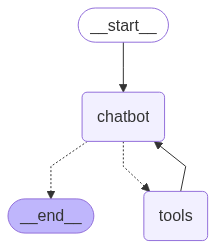

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)
@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""    ###Docstring is important as it contains "assistance".
    human_response = interrupt({"query": query})
    return human_response["data"]

tools = [wiki, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.

    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")



memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)



from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass



In [ ]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (0q1rfn62n)
 Call ID: 0q1rfn62n
  Args:
    query: I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?


In [ ]:
# So from above it expects human response


human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)
human_command = Command(resume={"data": human_response}) # resuming the flow
events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (0q1rfn62n)
 Call ID: 0q1rfn62n
  Args:
    query: I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

The experts recommend using **LangGraph** to build your AI agent! 🚀 Here's why:

**LangGraph** is a framework for building **graph-based agents** that:
1. **Outperform simple autonomous agents** by structuring workflows as directed acyclic graphs (DAGs)
2. Enable **reliable, production-grade systems** with better error handling and state management
3. Support **modular componen

# Different Types of Agents

In [2]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=""

In [4]:


from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver



In [8]:
class AgentState(MessagesState):
    next_agent:str # which agent should go next

In [6]:
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    # Using Tavily for web search
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    # Simple summary generation
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [7]:
from langchain.chat_models import init_chat_model

llm=init_chat_model("groq:llama-3.1-8b-instant")
llm


ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x7c47b332a8d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7c47b2e9dd90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [9]:
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""

    messages = state["messages"]

    # Add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")

    # Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)

    # Return the response and route to writer
    return {
        "messages": [response],
        "next_agent": "writer"
    }



In [10]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""

    messages = state["messages"]

    # Add system message
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")

    # Simple completion without tools
    response = llm.invoke([system_msg] + messages)

    return {
        "messages": [response],
        "next_agent": "end"
    }


In [11]:
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]

    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        # Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response

    # No tools to execute
    return state

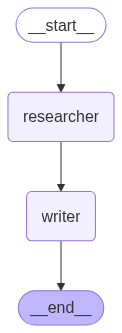

In [12]:
# Build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)

# Define flow
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)
final_workflow=workflow.compile()

final_workflow

In [13]:
response=final_workflow.invoke({"messages":"Reasearch about the usecase of agentic ai in business"})
response["messages"][-1].content

" \n\nBased on the research findings, here's a summary of the potential use cases of agentic AI in business:\n\n**Overview**\n\nAgentic AI refers to artificial intelligence (AI) systems that possess autonomous decision-making capabilities, allowing them to take actions on behalf of humans. In business, agentic AI has the potential to revolutionize various sectors by increasing efficiency, productivity, and competitiveness. The following use cases highlight the potential applications of agentic AI in business:\n\n**1. Customer Service and Support**\n\nAgentic AI can be used to create virtual customer support agents that can interact with customers, understand their concerns, and provide personalized solutions. This can lead to improved customer satisfaction, reduced response times, and increased sales.\n\n**2. Predictive Maintenance and Quality Control**\n\nAgentic AI can analyze data from sensors and equipment to predict when maintenance is required, reducing downtime and improving ove

# Supervised Multi Agent AI architecture

In [14]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

In [15]:
# ===================================
# State Definition
# ===================================

# ===================================
# State Definition
# ===================================

class SupervisorState(MessagesState):
    """State for the multi-agent system"""
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""

In [16]:
# ===================================
# Supervisor with Groq LLM
# ===================================
from langchain_core.prompts import ChatPromptTemplate
def create_supervisor_chain():
    """Creates the supervisor decision chain"""

    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:

1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
"""),
        ("human", "{task}")
    ])

    return supervisor_prompt | llm


In [18]:
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""

    messages = state["messages"]
    task = messages[-1].content if messages else "No task"

    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))

    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report
    })

    # Parse decision
    decision_text = decision.content.strip().lower()
    print(decision_text)

    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = "📋 Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "📋 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📋 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: Task seems complete."

    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }


In [19]:


# ===================================
# Agent 1: Researcher (using Groq)
# ===================================

def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""

    task = state.get("current_task", "research topic")

    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies

    Be concise but thorough."""

    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content

    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."

    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }



In [20]:
# ===================================
# Agent 2: Analyst (using Groq)
# ===================================

def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""

    research_data = state.get("research_data", "")
    task = state.get("current_task", "")

    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}"""

    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content

    # Create agent message
    agent_message = f"📊 Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:400]}..."

    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [21]:


# ===================================
# Agent 3: Writer (using Groq)
# ===================================

def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""

    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")

    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

Task: {task}

Research Findings:
{research_data[:1000]}

Analysis:
{analysis[:1000]}

Create a well-structured report with:
1. Executive Summary
2. Key Findings
3. Analysis & Insights
4. Recommendations
5. Conclusion

Keep it professional and concise."""

    # Get report from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content

    # Create final formatted report
    final_report = f"""
📄 FINAL REPORT
{'='*50}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Topic: {task}
{'='*50}

{report}

{'='*50}
Report compiled by Multi-Agent AI System powered by Groq
"""

    return {
        "messages": [AIMessage(content=f"✍️ Writer: Report complete! See below for the full document.")],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }



In [22]:


# ===================================
# Router Function
# ===================================

def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""

    next_agent = state.get("next_agent", "supervisor")

    if next_agent == "end" or state.get("task_complete", False):
        return END

    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent

    return "supervisor"



In [23]:


# Create workflow
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END
        }
    )

graph=workflow.compile()




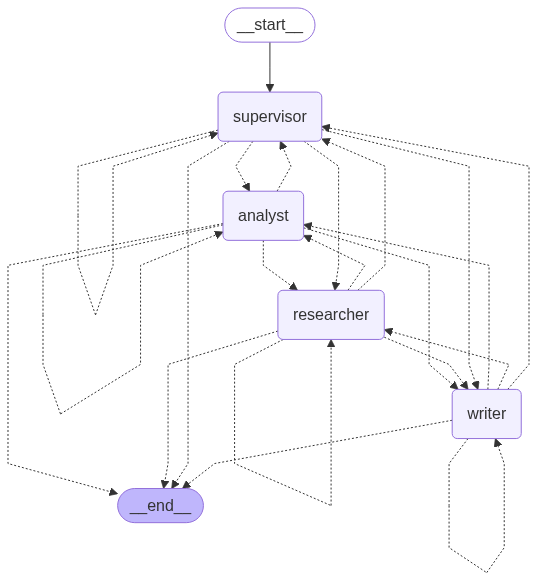

In [24]:
graph

In [28]:
response=graph.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))
response['final_report']

researcher
analyst
writer


"\n📄 FINAL REPORT\n==================================================\nGenerated: 2025-07-21 13:20\nTopic: 📊 Analyst: I've completed the analysis.\n\nTop insights:\n**Analysis and Insights on Space Exploration**\n\nGiven the provided research data on space exploration, here are the key insights, patterns, strategic implications, risks, opportunities, and recommendations:\n\n**1. Key Insights and Patterns:**\n\n- **Technological Advancements:** The cost of launching a satellite into orbit is decreasing due to reusability (e.g., SpaceX and Blue Origin), making space ...\n==================================================\n\n**Executive Report: Analysis and Insights on Space Exploration**\n\n**Date:** July 21, 2024\n\n**Prepared by:** [Your Name]\n\n**To:** [Recipient's Name]\n\n**Subject:** Analysis and Insights on Space Exploration\n\n**Executive Summary:**\n\nThis report presents key findings and insights on the current state of space exploration, highlighting technological advancement